In [1]:
import numpy as np
import scipy
from scipy import ndimage

import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
import os
import re

import cv2
import imageio.v3 as iio
from PIL import Image
from google.colab.patches import cv2_imshow
import time
import matplotlib.pyplot as plt
import matplotlib

import copy
import natsort

import networkx as nx
import umap
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as fun
import torchvision.transforms as trans

In [2]:
def rand_sign():
    return 1 if np.random.rand() < 0.5 else -1

In [3]:
class Universe():

    def __init__(self,size_universe):

        self.size_universe = size_universe

        #self.config = "open_field"
        self.config = "box_field"

        self.uni_mat = np.zeros((self.size_universe,self.size_universe,3))

    def update_uni_mat(self,pos_y,pos_x,color_value,hidden_value=0):

        self.uni_mat[int(pos_y),int(pos_x),:] = color_value

    def draw_edges(self):

        thickness = 3

        self.uni_mat[:,0:thickness,:] = [0,0,1]
        self.uni_mat[:,self.size_universe-thickness:self.size_universe,:] = [0,0,1]

        self.uni_mat[0:thickness,:,:] = [0,0,1]
        self.uni_mat[self.size_universe-thickness:self.size_universe,:,:] = [0,0,1]

    def add_object_to_uni(self,current_object):

        ob_size = current_object.body_size
        ob_color = current_object.body_color

        self.uni_mat[int(current_object.pos_y)-ob_size:int(current_object.pos_y)+ob_size,
                     int(current_object.pos_x)-ob_size:int(current_object.pos_x)+ob_size,:] += ob_color #[.7,.45,.100]

        #self.uni_mat[int(current_object.pos_y),int(current_object.pos_x),:] += [1,0,1] #[.7,.45,.100]

    def clear_previous_object (self,prev_object):

        ob_size = prev_object.body_size
        ob_color = prev_object.body_color

        self.uni_mat[int(prev_object.pos_y)-ob_size:int(prev_object.pos_y)+ob_size,
                     int(prev_object.pos_x)-ob_size:int(prev_object.pos_x)+ob_size,:] -= ob_color

        #self.uni_mat[int(prev_object.pos_y),int(prev_object.pos_x),:] -= [1,0,1]

    def add_inam_object_to_uni(self,current_object):

        ob_size_x = current_object.body_size_x
        ob_size_y = current_object.body_size_y
        ob_color = current_object.body_color

        self.uni_mat[int(current_object.pos_y)-ob_size_y:int(current_object.pos_y)+ob_size_y,
                     int(current_object.pos_x)-ob_size_x:int(current_object.pos_x)+ob_size_x,:] = \
        self.uni_mat[int(current_object.pos_y)-ob_size_y:int(current_object.pos_y)+ob_size_y,
             int(current_object.pos_x)-ob_size_x:int(current_object.pos_x)+ob_size_x,:] +  ob_color #[.7,.45,.100]



    def clear_previous_inam_object (self,prev_object):

        ob_size_x = current_object.body_size_x
        ob_size_y = current_object.body_size_y
        ob_color = current_object.body_color

        self.uni_mat[int(current_object.pos_y)-ob_size_y:int(current_object.pos_y)+ob_size_y,
                     int(current_object.pos_x)-ob_size_x:int(current_object.pos_x)+ob_size_x,:] = [0,0,0] #[.7,.45,.100]




    def gaussian_2d(self, x, y, mean, cov):
        """Generate a 2D Gaussian distribution."""
        inv_cov = np.linalg.inv(cov)
        diff = np.dstack((x - mean[0], y - mean[1]))
        exponent = -0.5 * np.einsum('...k,kl,...l->...', diff, inv_cov, diff)
        return np.exp(exponent)

    def create_energy_field(self, size_array, total_sum):
        # Create a zero array of size (size_array x size_array)
        array = np.zeros((size_array, size_array))

        # Create a meshgrid for the array
        x = np.linspace(0, size_array - 1, size_array)
        y = np.linspace(0, size_array - 1, size_array)
        x, y = np.meshgrid(x, y)

        # Generate 4 random means and very broad covariances
        means = [np.random.uniform(20, 80, 2) for _ in range(4)]
        covariances = [np.diag(np.random.uniform(200, 400, 2)) for _ in range(4)]  # Further increased covariance values for broader Gaussians

        # Add the 2D Gaussians to the array
        for mean, cov in zip(means, covariances):
            array += self.gaussian_2d(x, y, mean, cov)

        # Normalize the array to have the desired total sum
        array *= total_sum / np.sum(array)

        # Ensure the minimum value is at least 0.01
        min_value = np.min(array)
        if min_value < 0.01:
            array += (0.01 - min_value)
            array *= total_sum / np.sum(array)  # Renormalize after adjustment

        # Ensure the maximum value is higher (e.g., closer to 1.0)
        max_value = np.max(array)
        if max_value < 1.0:
            # Increase the overall scaling factor
            array *= 1.0 / max_value
            # Renormalize to ensure the total sum is still 2000
            array *= total_sum / np.sum(array)

        return array




In [4]:
class Agent ():

    def __init__(self,pos_x, pos_y,pred_potential):

        self.type = "agent"

        self.pos_x = pos_x
        self.pos_y = pos_y
        self.vel_x = 0.0
        self.vel_y = 0.0

        self.legal_move = True

        self.energy = 0
        self.reward_for_repr = 0

        self.body_size = 1 #+ int(self.energy/10)

        #self.pred_potential = rand_sign()*1
        self.pred_potential = pred_potential


        if self.pred_potential < 0:
            #self.body_color = [0,(-1)*self.pred_potential/2,0]
            self.body_color = [0,0,1]

        if self.pred_potential > 0:
            self.body_color = [0.5,0,0]
            #self.body_color = [self.pred_potential/10,0,1-self.pred_potential/10]


        self.sense_sq_area = 26

        self.input_net_size = self.sense_sq_area*self.sense_sq_area*3
        self.hidden_net_size_1 = 80
        self.output_net_size = 9

        self.epsilon_hidden_size = 10

        self.numb_of_hyperparams = 10

        self.model =  ModelNet(self.input_net_size,
                           self.hidden_net_size_1,
                           self.output_net_size ,
                           B_hyper_param= np.ones((self.numb_of_hyperparams)))


    def create_all_learnable_params(self,solution,list_elim_hidden,list_elim_hidden_out):

        sens_net_size =  self.input_net_size
        hidden_net_size_1= self.hidden_net_size_1
        output_net_size = self.output_net_size

        numb_of_hyperparams = self.numb_of_hyperparams

        #list_elim_hidden = [20,58,63,70]
        #list_elim_hidden = []


        idx1 = sens_net_size*hidden_net_size_1
        idx2 = idx1 + hidden_net_size_1*hidden_net_size_1
        idx3 = idx2 + hidden_net_size_1*output_net_size
        idx4 = idx3 + sens_net_size * 10
        idx5 = idx4 + 10  # sol_epsilon_hidden
        idx6 = idx5 + sens_net_size #sol_th_sens
        idx7 = idx6 + hidden_net_size_1 #sol_leak_hidden_layer
        idx8 = idx7 + output_net_size

        # Extract and reshape weight matrices
        W_sens_hidden = np.reshape(solution[:idx1], (sens_net_size, hidden_net_size_1) )
        W_hidden = np.reshape(solution[idx1:idx2],  (hidden_net_size_1, hidden_net_size_1) )
        W_hidden_out = np.reshape(solution[idx2:idx3], (hidden_net_size_1,output_net_size) )



        W_hidden[np.absolute(W_hidden) < 0.0] = 0

        W_hidden[list_elim_hidden,:] = 0
        W_hidden_out[list_elim_hidden_out,:] = 0


        W_epsilon_sens = np.reshape(solution[idx3:idx4], (sens_net_size, 10))
        W_epsilon_hidden = np.reshape(solution[idx4:idx5], (10, 1))

        leak_hidden_layer = np.absolute(solution[idx6:idx7])

        #sol_th_sens = solution[idx5:idx6]
        #sol_th_hidden = solution[idx6:idx7]
        #sol_th_out = solution[idx7:idx8]

        #sol_th_sens[sol_th_sens<0] = 0
        #sol_th_hidden[sol_th_hidden<0] = 0
        #sol_th_out[sol_th_out<0] = 0


        B_hyper_param = solution[-numb_of_hyperparams::]


        W_sens_hidden = nn.Parameter(torch.from_numpy(W_sens_hidden).float())
        W_hidden = nn.Parameter(torch.from_numpy(W_hidden).float())
        W_hidden_out = nn.Parameter(torch.from_numpy(W_hidden_out).float())
        W_epsilon_sens = nn.Parameter(torch.from_numpy(W_epsilon_sens).float())
        W_epsilon_hidden = nn.Parameter(torch.from_numpy(W_epsilon_hidden).float())

        leak_hidden_layer = nn.Parameter(torch.from_numpy(leak_hidden_layer).float())


        #sol_th_sens= nn.Parameter(torch.from_numpy(sol_th_sens).float())
        #sol_th_hidden = nn.Parameter(torch.from_numpy(sol_th_hidden).float())
        #sol_th_out = nn.Parameter(torch.from_numpy(sol_th_out).float())

        #return  W_sens_hidden,W_hidden, W_hidden_out, W_epsilon_sens, W_epsilon_hidden,  sol_th_sens, sol_th_hidden, sol_th_out, B_hyper_param
        return  W_sens_hidden,W_hidden, W_hidden_out, W_epsilon_sens, W_epsilon_hidden,  leak_hidden_layer, B_hyper_param



    def take_discrete_action(self,output):

        if np.max(output)>0:

            output_rs = np.reshape(output,(3,3))
            ind = np.where(output_rs==np.max(np.max(output_rs)))
            rand_ind = np.random.randint(0,np.shape(ind)[1])

            move_row=ind[0][rand_ind]-1
            move_col=ind[1][rand_ind]-1

        else:
            move_row=0
            move_col=0

        return move_row,move_col



    def move_discrete(self, move_row, move_col,uni):

        open_field = game_cont.open_field

        pos_new_x = self.pos_x + move_col
        pos_new_y = self.pos_y + move_row

        if open_field == True:

            pos_min = 7
            pos_max = uni.size_universe-7

            if pos_new_x > pos_max:
                pos_new_x = pos_min + 1
            if pos_new_y > pos_max:
                pos_new_y = pos_min + 1
            if pos_new_x < pos_min:
                pos_new_x = pos_max - 1
            if pos_new_y < pos_min:
                pos_new_y = pos_max - 1

        if open_field == False:

            edge_thick = 3

            pos_min = edge_thick
            pos_max = uni.size_universe-edge_thick

            if pos_new_x > pos_max:
                pos_new_x = pos_max
            if pos_new_y > pos_max:
                pos_new_y = pos_max
            if pos_new_x < pos_min:
                pos_new_x = pos_min
            if pos_new_y < pos_min:
                pos_new_y = pos_min

        self.pos_x = pos_new_x
        self.pos_y = pos_new_y


    def move_contin(self,move_row, move_col, uni, open_field=False):

        #open_field = game_cont.open_field
        size_universe =  uni.size_universe

        pers = 1
        drag = 0.1

        vel_max = 1
        vel_min = -1

        self.vel_x = self.vel_x + move_col/pers
        self.vel_y = self.vel_y + move_row/pers

        #self.vel_x = self.vel_x - (np.sign(self.vel_x)*drag)
        #self.vel_y = self.vel_y - (np.sign(self.vel_y)*drag)

        if self.vel_x > vel_max:
            self.vel_x = vel_max
        if self.vel_y > vel_max:
            self.vel_y = vel_max

        if self.vel_x < vel_min:
            self.vel_x = vel_min
        if self.vel_y < vel_min:
            self.vel_y = vel_min

        pos_new_x = self.pos_x + self.vel_x
        pos_new_y = self.pos_y + self.vel_y

        if open_field == True:

            pos_min = 7
            pos_max = size_universe-7

            if pos_new_x > pos_max:
                pos_new_x = pos_min + 1
            if pos_new_y > pos_max:
                pos_new_y = pos_min + 1
            if pos_new_x < pos_min:
                pos_new_x = pos_max - 1
            if pos_new_y < pos_min:
                pos_new_y = pos_max - 1

        if open_field == False:

            edge_thick = 3

            pos_min = edge_thick+self.body_size
            pos_max = size_universe-edge_thick-self.body_size

            if pos_new_x > pos_max:
                pos_new_x = pos_max
            if pos_new_y > pos_max:
                pos_new_y = pos_max
            if pos_new_x < pos_min:
                pos_new_x = pos_min
            if pos_new_y < pos_min:
                pos_new_y = pos_min

        self.pos_x = int(pos_new_x)
        self.pos_y = int(pos_new_y)


    def accelerate(self, acc_x, acc_y):
        self.vel_x = self.vel_x + acc_x
        self.vel_y = self.vel_y + acc_y

    def add_self_to_sense_image(self,raw_im):

        ob_size_x = self.body_size
        ob_size_y = self.body_size
        ob_color = self.body_color #add to blue channel

        raw_im[13-ob_size_y:13+ob_size_y,
             #int(self.pos_x)-ob_size_x:int(self.pos_x)+ob_size_x,2] = 1 #[.7,.45,.100]
             13-ob_size_x:13+ob_size_x,2] = ob_color[0] #[.7,.45,.100]

        return raw_im


    def sense(self,uni_mat):

        open_field = False
        #open_field = True

        #open_field = game_cont.open_field

        #sense_cube = np.zeros((self.sense_sq_area, self.sense_sq_area, 3))

        if open_field == True:

            uni_mat_tiled = np.tile(uni_mat,(3,3,1))

            pos_r = np.shape(uni_mat)[0] + int(self.pos_y)
            pos_c = np.shape(uni_mat)[1] + int(self.pos_x)

            sense_cube = uni_mat_tiled[pos_r-int(self.sense_sq_area/2):pos_r+int(self.sense_sq_area/2) ,
                         pos_c-int(self.sense_sq_area/2):pos_c+int(self.sense_sq_area/2) ,:]

        if open_field == False:

            uni_mat_tiled = np.tile(uni_mat,(3,3,1))
            uni_mat_tiled[0:np.shape(uni_mat)[0],:,:] = [0,0,0]
            uni_mat_tiled[np.shape(uni_mat)[0]*2:np.shape(uni_mat)[0]*3,:,:] = [0,0,0]

            uni_mat_tiled[:,0:np.shape(uni_mat)[0],:] = [0,0,0]
            uni_mat_tiled[:,np.shape(uni_mat)[0]*2:np.shape(uni_mat)[0]*3,:] = [0,0,0]

            pos_r = np.shape(uni_mat)[0] + int(self.pos_y)
            pos_c = np.shape(uni_mat)[1] + int(self.pos_x)

            sense_cube = uni_mat_tiled[pos_r-int(self.sense_sq_area/2):pos_r+int(self.sense_sq_area/2) ,
                         pos_c-int(self.sense_sq_area/2):pos_c+int(self.sense_sq_area/2) ,:]


        im = sense_cube
        im = np.transpose(im,(2,0,1))
        im = np.expand_dims(im,axis=0)
        im = torch.tensor(im,dtype=torch.float32)

        raw_im=self.add_self_to_sense_image(sense_cube)

        return im, raw_im


    def update_energy (self,count):

        max_energy = 100

        if count <= 1:
            self.energy = self.energy + 15

        if count > 1:
            self.energy = self.energy - (count -1)*5

        if self.energy < 0:
            self.energy = 0

        if self.energy > max_energy:
            self.energy = max_energy

In [5]:

class ModelNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, B_hyper_param):
        super(ModelNet, self).__init__()

        # Initialize hyperparameters
        self.B_hyper_param = B_hyper_param

        self.hidden_max = B_hyper_param[0] * 10000
        self.add_hidden = B_hyper_param[1] * 0.5
        self.add_sens = B_hyper_param[2] * 0.01
        self.leak_sens = B_hyper_param[3] * 0.1
        self.leak_hidden = B_hyper_param[4] * 0.1
        self.max_epsilon = B_hyper_param[5] * 1


        self.W_epsilon_sens = nn.Parameter(torch.randn(input_size, hidden_size))  # (input_size, hidden_size)
        self.W_epsilon_hidden = nn.Parameter(torch.randn(hidden_size, output_size))  # (hidden_size, output_size)

        self.W_sens_hidden = nn.Parameter(torch.randn(input_size, hidden_size))  # (input_size, hidden_size)
        self.W_hidden = nn.Parameter(torch.randn(hidden_size, hidden_size))  # (hidden_size, hidden_size)
        self.W_hidden_out = nn.Parameter(torch.randn(hidden_size, output_size))  # (hidden_size, output_size)

        self.hidden_layer = torch.zeros(hidden_size)
        self.out_layer = torch.zeros(output_size)

        self.leak_hidden_layer = torch.zeros(hidden_size)

        #self.th_sens = np.random.uniform(0,1, input_size)
        #self.th_hidden = np.random.uniform(0,1, hidden_size)
        #self.th_out = np.random.uniform(0,1, output_size)

        self.hidden_net_size_1 = hidden_size
        self.numb_outputs = output_size



    def forward(self, input_state):

        self.hidden_max = self.B_hyper_param[0] * 10000
        self.add_hidden = self.B_hyper_param[1] * 0.5
        self.add_sens = self.B_hyper_param[2] * 0.01
        self.leak_sens = self.B_hyper_param[3] * 0.1
        self.leak_hidden = self.B_hyper_param[4] * 0.5
        self.max_epsilon = self.B_hyper_param[5] * 1

        # Flatten the input state
        trans_state = input_state.view(-1)  # Shape: (input_size,)
        trans_state = trans_state*1
        ######################################################
        # Compute epsilon values

        #epsilon_hidden_layer = torch.matmul(trans_state, self.W_epsilon_sens)  # Shape: (hidden_size,)
        #epsilon = torch.matmul(epsilon_hidden_layer, self.W_epsilon_hidden)  # Shape: (output_size,)
        #epsilon = torch.clamp(epsilon, -self.max_epsilon, self.max_epsilon)

        #epsilon = epsilon*0

        epsilon = self.hidden_layer[79]*100
        epsilon = torch.clamp(epsilon, 0, self.max_epsilon)*1
       # print(epsilon)


        ##################################################################



        trans_state = torch.matmul(self.W_sens_hidden.T,trans_state.view(-1, 1))
        trans_state = trans_state.squeeze(1)
        #print( trans_state.shape )

        trans_state = torch.clamp(trans_state, 0, self.hidden_max)

        # Update hidden layer with recurrent effects
        recurrent_effect = torch.matmul(self.W_hidden,self.hidden_layer)

        #print(np.sum(self.hidden_layer))
        #print(self.leak_hidden, type(self.leak_hidden))
        #print("hidden_layer size:", self.hidden_layer.shape)
        #print("leak_hidden:", self.leak_hidden)
        #print("trans_state size:", trans_state.shape)
        #print("recurrent_effect size:", recurrent_effect.shape)
        #print("th_hidden size:", self.th_hidden.shape)

        #print(torch.min(trans_state))

        self.hidden_layer = (
            self.hidden_layer - self.leak_hidden_layer*self.hidden_layer
        )

        self.hidden_layer = torch.clamp(self.hidden_layer, 0, self.hidden_max)

        self.hidden_layer = (
            self.hidden_layer - self.leak_hidden*self.hidden_layer
            + trans_state * self.add_sens
            + recurrent_effect * self.add_hidden
            #- self.th_hidden
        )

       ## print(self.leak_hidden)
        self.hidden_layer = torch.clamp(self.hidden_layer, 0, self.hidden_max)  # Shape: (hidden_size,)

        # Compute output layer
        #self.out_layer = torch.matmul(self.hidden_layer, self.W_hidden_out)  # Shape: (output_size,)
        self.out_layer = torch.matmul(self.W_hidden_out.T,self.hidden_layer)
        #self.out_layer = torch.clamp(self.out_layer, 0, self.hidden_max)
        # Add noise
        N_out = torch.randn(self.numb_outputs) * self.out_layer * epsilon
        #print(N_out)
        #print(self.out_layer)
        #print(epsilon)
        final_state = self.out_layer + N_out  # Shape: (output_size,)
        final_state = torch.clamp(final_state, min=0)  # Shape: (output_size,)

        return final_state

In [6]:
class Evolution():

    def __init__(self,):

        self.evo_type = 0

    def fitness_func_GA(ga_instance, solution, solution_idx):

        pop_curr = ga_instance.population
        print(solution_idx)

        fitness = 0
        TIME_TOT = 1000

        for r in range(0,3):

            fitness1 = run_episode(solution,pop_curr,popul_prey,solution_idx,TIME_TOT,display_movie=False,record_data=False)
            fitness = fitness + fitness1

        #if fitness > 0:
        print(fitness)

        return fitness


    def fitness_func(self,solution, pop_curr):

        TIME_TOT = 1000
        fitness_vect = np.zeros((1,np.shape(pop_curr)[0]))

        for r in range(0,3):

            #ts=time.time()
            fitness_vect1, raw_im,list_of_agents, data_rec_dic = run_episode(solution,popul,TIME_TOT,display_movie=False,record_data=False)
            fitness_vect = fitness_vect + fitness_vect1
            #te=time.time()
            #print(ts-te)

        return fitness_vect


    def mutate(self,sol,mut_rate,mut_amp,mut_type="add_rand_val"):

        sol_next = np.copy(sol)
        #mask_mut = np.ones_like(sol)
        m_ind_vect = np.random.randint(len(sol), size=int(len(sol)*mut_rate))

        numb_of_hyperparams = 10

        if mut_type == "add_rand_val":

            for m in range(0,len(m_ind_vect)):
                if sol[m_ind_vect[m]] != 0:
                    sol_next[m_ind_vect[m]] = sol[m_ind_vect[m]]+np.random.rand()*rand_sign()*mut_amp

        if mut_type == "mask":

            for m in range(0,len(m_ind_vect)-numb_of_hyperparams):
                #mut_triplet = [0,np.random.rand()*rand_sign(),1]

                if sol[m_ind_vect[m]] == 0:
                    sol_next[m_ind_vect[m]]=np.random.rand()*rand_sign()*mut_amp
                if sol[m_ind_vect[m]] != 0:
                    sol_next[m_ind_vect[m]]=0


                #mask_mut[m_ind_vect[m]] = mut_triplet[np.random.randint(0,3)]

        return sol_next

    def fitness_func_dust(self,solution,pop_curr):

        TIME_TOT = 1000
        fitness_vect = np.zeros((1,np.shape(pop_curr)[0]))
        #fitness_vect1 = np.zeros((1,np.shape(pop_curr)[0]))

        for s in range(np.shape(pop_curr)[0]):

            solution = pop_curr[s,:]
            fitness_sol = 0

            for r in range(0,3):

                dust_removed_tot, rgbArray, ag, output, energy_field, data_rec_dic  = run_episode (solution,TIME_TOT,display_movie=False,record_data=False)
                fitness_sol =  fitness_sol + dust_removed_tot

                Wh = ag.model.W_hidden.detach().cpu().numpy()
                Wo = ag.model.W_hidden_out.detach().cpu().numpy()
                #param_cost = (np.count_nonzero(Wh) + np.count_nonzero(Wo))/(np.size(Wh) + np.size(Wo))
                param_cost =  (np.count_nonzero(Wh) + np.count_nonzero(Wo))/100

            #fitness_vect[0,s] = fitness_sol/(param_cost*3)
            fitness_vect[0,s] = fitness_sol #- param_cost #- energy_loss

        return fitness_vect

    def mutate(self,sol,mut_rate,mut_amp,mut_type="add_rand_val"):

        numb_of_hyperparams = 10

        sol_next = np.copy(sol)
        #mask_mut = np.ones_like(sol)
       # m_ind_vect = np.random.randint(len(sol)-numb_of_hyperparams, size=int(len(sol)*mut_rate))



        if mut_type == "add_rand_val":

            m_ind_vect = np.random.randint(len(sol), size=int(len(sol)*mut_rate))

            for m in range(0,len(m_ind_vect)):
                if sol[m_ind_vect[m]] != 0:
                    sol_next[m_ind_vect[m]] = sol[m_ind_vect[m]]+np.random.rand()*rand_sign()*mut_amp

        if mut_type == "mask":

            m_ind_vect = np.random.randint(len(sol)-numb_of_hyperparams, size=int(len(sol)*mut_rate))

            #mask_lim1 = 245760 #size of sens_hidden W
            #mask_lim2 = 245760 + 6400 + 1200 #size of sens_hidden W

            for m in range(0,len(m_ind_vect)-numb_of_hyperparams):
            #for m in range(mask_lim1,mask_lim2):
                #mut_triplet = [0,np.random.rand()*rand_sign(),1]

                if sol[m_ind_vect[m]] == 0:
                    sol_next[m_ind_vect[m]]=np.random.rand()*rand_sign()*mut_amp
                if sol[m_ind_vect[m]] != 0:
                    sol_next[m_ind_vect[m]]=0

        if mut_type == "mixed":

            m_ind_vect = np.random.randint(len(sol), size=int(len(sol)*mut_rate))

            for m in range(0,len(m_ind_vect)):
                if sol[m_ind_vect[m]] != 99999999:
                    sol_next[m_ind_vect[m]] = sol[m_ind_vect[m]]+np.random.rand()*rand_sign()*mut_amp

                #mask_mut[m_ind_vect[m]] = mut_triplet[np.random.randint(0,3)]

        return sol_next


    def find_oldest_file(self,file_list):
        ages_vec = np.zeros((len(file_list),1))

        for f in range(len(file_list)):
            fl_str=file_list[f]
            ages_vec[f]=int(re.findall(r'\d+', fl_str)[1])

        oldest_file =  np.argmin(ages_vec)
        return oldest_file

    def remove_oldest_indiv(self,pool_folder_name, min_pool_size):

        file_list = os.listdir(pool_folder_name)
        if len(file_list) > min_pool_size:
            ind_oldest = self.find_oldest_file(file_list)
            name_of_oldest = pool_folder_name+file_list[ind_oldest]
            os.remove(name_of_oldest)

    def add_to_pool_1 (self,popul,fitness_vect,pool_folder_name, max_pool_size,gen_ind=0):

        energy_in_universe = 1000

        pool_saving_size = 10
        #max_pool_size = 2000

        fit_vect_rel = (fitness_vect/(energy_in_universe*1))*pool_saving_size
        to_next_gen_in_pool = np.floor(fit_vect_rel)

        #print(fit_vect_rel)

        if np.max(to_next_gen_in_pool) < 1:
            #print(to_next_gen_in_pool)
            to_next_gen_in_pool[0,np.argmax(fitness_vect)]=1
            #print(to_next_gen_in_pool)

        n=0

        for indiv in range(0,np.shape(to_next_gen_in_pool)[1]):

            sol = np.expand_dims(popul[indiv,:],axis=0)
            n = to_next_gen_in_pool[0,indiv]

            for ind_save in range(0,int(n)):
                sol_sparse = scipy.sparse.csr_matrix(sol)
                sol_name = f"{pool_folder_name}_{int(fitness_vect[0,indiv])}_solution_{gen_ind}_{int(ind_save)}"
                with open(sol_name, "wb") as f:
                    pickle.dump(sol_sparse, f)

            file_list = os.listdir(pool_folder_name)
            if len(file_list) > max_pool_size:
                numb_delete_files = int(len(file_list)-max_pool_size)
                sl=natsort.natsorted(file_list)
                for d in range(0, numb_delete_files):
                    name_del_file = pool_folder_name+sl[d]
                    #print(name_del_file)
                    os.remove(name_del_file)


    def select_popul_from_pool_1(self,numb_samples,pool_folder_name):

        file_list = os.listdir(pool_folder_name)
        if len(file_list)==0:
            #new_sol=construct_init_solution(zero_init=True)
            #new_sol=construct_init_solution(init_type="mixed")
            new_sol=construct_init_solution(init_type="zeros")

            select_popul = np.zeros((numb_samples,np.shape(new_sol)[0]))
            #select_popul = np.random.rand(numb_samples,np.shape(new_sol)[0])
            for r in range(0,numb_samples+0):
                #select_popul[r,:] = construct_init_solution(init_type="mixed")
                select_popul[r,:] = construct_init_solution(init_type="zeros")

        if len(file_list)>0:

            file_ind_vect = np.random.randint(len(file_list), size=int(numb_samples))

            selected_file_name = file_list[file_ind_vect[0]]
            with open(pool_folder_name + selected_file_name, "rb") as f:
                sol_sparse = pickle.load(f)

            if scipy.sparse.issparse(sol_sparse) == True:

                select_popul = sol_sparse.toarray()

            else:

                 select_popul = np.expand_dims(sol_sparse,axis=0)

            for s in range(1,numb_samples):

                selected_file_name = file_list[file_ind_vect[s]]

                with open(pool_folder_name + selected_file_name, "rb") as f:
                    sol_sparse = pickle.load(f)

                if scipy.sparse.issparse(sol_sparse) == True:
                    sol = sol_sparse.toarray()
                else:
                    sol = np.expand_dims(sol_sparse,axis=0)

                select_popul = np.vstack((select_popul,sol))

        return select_popul


In [7]:
class GameControl ():

    def __init__(self,open_field,leave_trace):

        self.rule = 'pred'
        self.max_pop = 5
        self.energy_change_predation = 5
        self.energy_change_movement = 1

        self.open_field = open_field
        #self.uni_mat = uni.uni_mat

        self.leave_trace = leave_trace


    def get_eu_dist(self,agent1, agent2):

        eu_dist = np.sqrt((agent1.pos_x - agent2.pos_x)**2 + (agent1.pos_y - agent2.pos_y)**2)
        return eu_dist

    def movement_consequences(self,agent,action):

        if action[0] == 0 and action[1] == 0:
            standing = True

        else: standing = False


        if agent.pred_potential > 0 and standing == False:
            agent.energy = agent.energy - 0.1
        if agent.pred_potential < 0 and standing == False:
            agent.energy = agent.energy + 0.1*(agent.pred_potential)



    def encounter(self,agent,list_of_agents):

        agent1 = agent

        total_encountered = 0


        for ind2,agent2 in enumerate(list_of_agents):

            if agent1 != agent2:

                eu_dist = self.get_eu_dist(agent1, agent2)
                #print(ind1,ind2,eu_dist)

                #eu_dist_th = (agent1.body_size + agent2.body_size)+2
                #eu_dist_th = 20

                eu_dist_th = np.sqrt((agent1.body_size*1)**2+(agent1.body_size*1)**2) + \
                np.sqrt((agent2.body_size*1)**2+(agent2.body_size*1)**2)

                eu_dist_th_legal = (agent1.body_size + agent2.body_size)

                if eu_dist < eu_dist_th_legal:
                    agent1.legal_move = False
                    #print("illegal")
                    #print(eu_dist)
                    break
                else: agent1.legal_move = True

                #energy_curr = agent1.energy

                #if eu_dist < eu_dist_th and agent1.pred_potential > 0 and agent2.pred_potential < 0:
                #if eu_dist < eu_dist_th and agent1.body_size > agent2.body_size:

                if eu_dist < eu_dist_th and agent1.energy > agent2.energy:
                #if eu_dist < eu_dist_th and agent1.energy < agent2.energy:

                    #agent1.energy = agent1.energy-np.absolute(agent2.energy/100)
                    #agent2.energy = agent2.energy-np.absolute(agent2.energy/100)

                    agent1.energy = agent1.energy+np.absolute(agent2.energy/10)
                    agent2.energy = agent2.energy-np.absolute(agent2.energy/10)

                    if agent1.energy<0: agent1.energy=0
                    if agent2.energy<0: agent2.energy=0



    def render_video(self, uni, list_of_ag):

        uni_mat = uni.uni_mat

        rgbArray = np.zeros(
            (uni_mat.shape[0], uni_mat.shape[1], 3),
            'uint8'
        )

        rgbArray[..., 0] = uni_mat[:, :, 2] * 255
        rgbArray[..., 1] = uni_mat[:, :, 1] * 255
        rgbArray[..., 2] = uni_mat[:, :, 0] * 255

        for ind_a, ag in enumerate(list_of_ag):

            nn_plot = ag.model.hidden_layer.detach().cpu().numpy()
            nn_plot = np.reshape(nn_plot, (8, 10))
            nn_plot = (nn_plot / np.max(np.max(nn_plot))) * 250

            if ag.pos_x < 90 and ag.pos_y < 90:

                rgbArray[
                    ag.pos_y:ag.pos_y+8,
                    ag.pos_x:ag.pos_x+10,
                    0
                ] = nn_plot

        # This is the frame
        #im_to_show = rgbArray

        im_to_show = np.array(Image.fromarray(rgbArray).resize((600, 600), Image.Resampling.NEAREST))

        return im_to_show

    """
    def render_video(self,uni,list_of_ag):

        uni_mat = uni.uni_mat

        rgbArray = np.zeros((uni_mat.shape[0],uni_mat.shape[1],3), 'uint8')
        rgbArray[..., 0] = uni_mat[:,:,2]*255
        rgbArray[..., 1] = uni_mat[:,:,1]*255
        rgbArray[..., 2] = uni_mat[:,:,0]*255

        for ind_a,ag in enumerate(list_of_ag):
            nn_plot = ag.model.hidden_layer.detach().cpu().numpy()
            nn_plot = np.reshape(nn_plot,(8,10))
            nn_plot = (nn_plot/np.max(np.max(nn_plot)))*250
            #nn_plot[nn_plot>250]=250

            if ag.pos_x<90 and ag.pos_y<90:

                rgbArray[ag.pos_y:ag.pos_y+8,
                         ag.pos_x:ag.pos_x+10, 0] = nn_plot



        im_to_show = rgbArray

        image_size_x = 600
        image_size_y = 600

        scaing_size = image_size_x/np.shape(uni_mat)[0]
        im_to_show = cv2.resize(im_to_show, (600, 600))

        #energy_text =  str(int(agent.energy))
        font = cv2.FONT_HERSHEY_SIMPLEX
        #org = (50, 20)
        #fontScale = 1
        #color = (255, 0, 0)
        #thickness = 2
        for ind_a,ag in enumerate(list_of_ag):
            #ag = list_of_ag[a]

            bc = ag.body_color

            ind_energy_text = str(int(ag.energy))
            org = (int(ag.pos_x*scaing_size), int(ag.pos_y*scaing_size))
            fontScale = 0.5
            color = (255-bc[0]*255, 255-bc[1]*255, 0-bc[2]*255)
            thickness = 2

            im_to_show = cv2.putText(im_to_show, ind_energy_text, org, font, fontScale,
                                     color, thickness, cv2.LINE_AA)

            ind_text = str(int(ind_a))
            org = (int(ag.pos_x*scaing_size), int(ag.pos_y*scaing_size)+12)
            fontScale = 0.5
            color = (255-bc[0]*255, 255-bc[1]*255, 0-bc[2]*255)
            thickness = 2

            im_to_show = cv2.putText(im_to_show, ind_text, org, font, fontScale,
                                     color, thickness, cv2.LINE_AA)

        #cv2.imshow('test_mat',im_to_show)
        clear_output(wait=True)
        cv2_imshow(im_to_show)

        plt.clf()

        if cv2.waitKey(1) & 0xFF == ord('q'):
            pass
            #break
        return im_to_show

   """

In [8]:
#construct solution initial

def construct_init_solution(init_type="zeros"):

    sens_net_size = 2028
    hidden_net_size_1=80
    output_net_size=9

    #if zero_init==True:
    if init_type =="zeros":

        W_sens_hidden=np.zeros((sens_net_size, hidden_net_size_1))
        W_hidden = np.zeros((hidden_net_size_1, hidden_net_size_1))
        W_hidden_out = np.zeros((hidden_net_size_1, output_net_size))

        #leak_hidden_layer = np.zeros((sens_net_size, 10))

        W_epsilon_sens = np.zeros((sens_net_size, 10))
        W_epsilon_hidden = np.zeros((10, 1))

    if init_type =="random":

        W_sens_hidden= np.random.uniform(-1,1,(sens_net_size, hidden_net_size_1))
        W_hidden = np.random.uniform(-1,1,(hidden_net_size_1, hidden_net_size_1))
        W_hidden_out = np.random.uniform(-1,1,(hidden_net_size_1, output_net_size))

        W_epsilon_sens = np.random.uniform(-1,1,(sens_net_size, 10))
        W_epsilon_hidden = np.random.uniform(-1,1,(10, 1))

    if init_type =="mixed":

        W_sens_hidden= np.random.uniform(-1,1,(sens_net_size, hidden_net_size_1))
        W_hidden = np.zeros((hidden_net_size_1, hidden_net_size_1))
        W_hidden_out = np.zeros((hidden_net_size_1, output_net_size))

        W_epsilon_sens = np.random.uniform(-1,1,(sens_net_size, 10))
        W_epsilon_hidden = np.random.uniform(-1,1,(10, 1))

    solution_sens = W_sens_hidden.flatten()
    solution_hidden = W_hidden.flatten()
    solution_out = W_hidden_out.flatten()

    solution_epsilon_sens = W_epsilon_sens.flatten()
    solution_epsilon_hidden = W_epsilon_hidden.flatten()
    #solution_epsilon = W_epsilon.flatten()
    #solution_epsilon = 0
    #solution_agent_pred_pot = 1

    general_th = 10

    sol_th_sens = np.random.uniform(0,1,sens_net_size)* general_th
    #sol_th_hidden = np.random.uniform(0,1,hidden_net_size_1) * general_th

    sol_leak_hidden_layer = np.random.uniform(0,1,hidden_net_size_1)

    sol_th_out = np.random.uniform(0,1,output_net_size) * general_th

    solution_hyperparams = np.ones((10))

    solution = np.hstack((solution_sens,solution_hidden,solution_out,
                          solution_epsilon_sens,solution_epsilon_hidden,
                          sol_th_sens,
                          sol_leak_hidden_layer,
                          sol_th_out,
                          solution_hyperparams))

    print(np.shape(solution_sens),np.shape(solution_hidden),np.shape(solution_out),
          np.shape(solution_epsilon_sens),np.shape(solution_epsilon_hidden))
    print(np.shape(solution))

    return solution


In [9]:

def create_new_agent (solution, size_universe):

    pos_x = int(np.random.rand()*size_universe)
    pos_y = int(np.random.rand()*size_universe)

    pred_pot = 1

    new_agent = Agent(pos_x, pos_y,pred_pot)

    input_net_size = new_agent.input_net_size
    hidden_net_size_1 = new_agent.hidden_net_size_1
    numb_outputs = new_agent.output_net_size
    epsilon_hidden_size = new_agent.epsilon_hidden_size

   # W_sens_hidden,W_hidden, W_hidden_out, W_epsilon_sens, W_epsilon_hidden,sol_th_sens, sol_th_hidden, sol_th_out, B_hyper_param  = new_agent.create_all_learnable_params(solution,
   #  list_elim_hidden,list_elim_hidden_out)

    W_sens_hidden,W_hidden, W_hidden_out, W_epsilon_sens, W_epsilon_hidden, leak_hidden_layer, B_hyper_param  = new_agent.create_all_learnable_params(solution,
     list_elim_hidden,list_elim_hidden_out)


    new_agent.model.W_sens_hidden = W_sens_hidden
    new_agent.model.W_hidden = W_hidden
    new_agent.model.W_hidden_out = W_hidden_out

    new_agent.model.W_epsilon_sens = W_epsilon_sens
    new_agent.model.W_epsilon_hidden = W_epsilon_hidden

    new_agent.model.leak_hidden_layer = leak_hidden_layer

    #new_agent.model.th_sens = sol_th_sens
    #new_agent.model.th_hidden = sol_th_hidden
    #new_agent.model.th_out = sol_th_out

    new_agent.model.B_hyper_param = B_hyper_param

    return new_agent

In [10]:

def run_episode(solution,popul,TOTAL_TIME, list_elim_hidden = [], list_elim_hidden_out = [],display_movie=False,record_data=False):

    start_new_universe = True

    frames = []

    if start_new_universe == True:

        open_field = False
        leave_trace = False

        size_universe = 100
        energy_in_universe=2000

        uni = Universe(size_universe)

        energy_field = uni.create_energy_field(size_universe,energy_in_universe)
        uni.uni_mat[:,:,1] = energy_field



    game_cont = GameControl(open_field,leave_trace)

    game_cont.leave_trace = False

    total_energy = 0

    st_rec_cube = np.zeros((100,100,5))

    numb_of_agents = np.shape(popul)[0]

    list_of_agents = []

    for a in range(0,numb_of_agents):
        solution_current = popul[a,:]
        new_agent = create_new_agent (solution_current, size_universe)
        new_agent.pred_potential = 1
        new_agent.body_color = [0.5,0,0]
        list_of_agents.append(new_agent)


    ########################################

    fitness_vect = np.zeros((1,numb_of_agents))

    #######################################

    if display_movie == True:

        result = cv2.VideoWriter('filename.avi',
                                 cv2.VideoWriter_fourcc(*'MJPG'),
                                 10, (600,600))

    ###########################################

    ########################################################


    if record_data == False:
        output_rec = []
        hidden_rec = []
        data_rec_dic = { "output_rec" : output_rec,
                         "hidden_rec" : hidden_rec}

    if record_data == True:

        ag = list_of_agents[0]

        output_rec = np.zeros((np.shape(ag.model.out_layer.detach().cpu().numpy())[0] , TIME_TOT ))
        hidden_rec = np.zeros((np.shape(ag.model.hidden_layer.detach().cpu().numpy())[0] , TIME_TOT ))

        pos_rec = np.zeros((2, TIME_TOT))

        data_rec_dic = { "output_rec" : output_rec,
                         "hidden_rec" : hidden_rec,
                         "pos_rec" :  pos_rec}


    ########################################################

    for t in range(0,TOTAL_TIME):
        for a in range(0,np.shape(list_of_agents)[0]):

            agent=list_of_agents[a]

            if game_cont.open_field == False:
                uni.draw_edges()

            #if game_cont.leave_trace == False:
            #    uni.clear_previous_object (agent)
            if t==0:
                uni.add_object_to_uni(agent)

            state, raw_im = agent.sense(uni.uni_mat)

            if game_cont.leave_trace == False:
                uni.clear_previous_object (agent)

            #ts=time.time()

            input_state = torch.from_numpy(raw_im).float()

            output = agent.model.forward(input_state)
            output = output.detach().cpu().numpy()
            #te=time.time()
            #if a==0:
               # print(ts-te)
            move_row, move_col = agent.take_discrete_action(output)

            #if a==5: print(move_row, move_col)

            #agent.move_discrete(move_row , move_col)
            agent.move_contin(move_row , move_col,uni, open_field)

            #if record_data==True:

                #st_rec_cube[agent.pos_y,agent.pos_x,0] = agent.model.epsilon
                #st_rec_cube[agent.pos_y,agent.pos_x,1] = agent.model.hidden_layer[19]
                #st_rec_cube[agent.pos_y,agent.pos_x,2] = agent.model.hidden_layer[0]
                #st_rec_cube[agent.pos_y,agent.pos_x,3] = agent.model.hidden_layer[8]

               # activity_rec_mat[:,t] = agent.model.hidden_layer


            if agent.pred_potential != 0:
                energy_added = energy_field[agent.pos_y,agent.pos_x]
                energy_field[agent.pos_y,agent.pos_x] = 0
                agent.energy = agent.energy + energy_added
                agent.body_size =  1 + int(np.sqrt(agent.energy)/5)

            if agent.energy<0:
                agent.energy=0

            uni.uni_mat[:,:,1] = energy_field

            game_cont.encounter(agent,list_of_agents)


            fitness_vect[0,a] = agent.energy


            uni.add_object_to_uni(agent)
            #ts = time.time()


        if record_data == True:
            output_rec[:,t] = output
            hidden_rec[:,t] = agent.model.hidden_layer.detach().cpu().numpy()

            pos_rec[0,t] = agent.pos_x
            pos_rec[1,t] = agent.pos_y


        if display_movie == True:

            frame = game_cont.render_video(uni, list_of_agents)
            frames.append(frame)

            """
            time.sleep(0.0001)
            frame = game_cont.render_video(uni,list_of_agents)
            result.write(frame)
            #cv2.imshow('Frame', frame)

            clear_output(wait=True) #try this
            cv2_imshow(frame)
            plt.clf()

            if cv2.waitKey(1) & 0xFF == ord('s'):
                break
            """

    param_cost = False
    if param_cost == True:
        param_cost_vect = np.expand_dims(np.count_nonzero(popul[:,:],axis=1),axis=0)
        fitness_vect = fitness_vect-param_cost_vect/300


    #cv2.destroyAllWindows()




    if record_data == False:
        data_rec_dic = None

    if record_data == True:
        data_rec_dic = { "output_rec" : output_rec,
                        "hidden_rec" : hidden_rec,
                        "pos_rec" :  pos_rec}

    if display_movie == True:

        iio.imwrite("simulation.mp4", frames, fps=20)

    return fitness_vect, raw_im, list_of_agents, data_rec_dic, frames

In [ ]:
solution = popul[0,:]

In [ ]:
#from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
evol =  Evolution()

pool_folder_name = "/content/drive/MyDrive/Colab Notebooks/pool_att_16p9_leakNew_fullRNN/"

popul = evol.select_popul_from_pool_1(3,pool_folder_name)
solution = popul[0,:]

/tmp/ipykernel_1465/2807217687.py:222: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  sol_sparse = pickle.load(f)
/tmp/ipykernel_1465/2807217687.py:237: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  sol_sparse = pickle.load(f)


In [ ]:
with open("demo_popul_att_16p9", "rb") as f:
    popul = pickle.load(f)

solution = popul[0,:]

FileNotFoundError: [Errno 2] No such file or directory: 'demo_popul_att_16p9'

In [ ]:
from IPython.display import clear_output

In [ ]:
TIME_TOT = 1000

list_elim_hidden = []
list_elim_hidden_out = []

ts=time.time()

fitness_vect, raw_im,list_of_agents, data_rec_dic, frames = run_episode(solution,popul,TIME_TOT,
                                                  list_elim_hidden,list_elim_hidden_out,
                                                  display_movie=False,record_data=True)
te=time.time()

print(ts-te)
print(np.round(fitness_vect))

ag=list_of_agents[0]

-4.999352693557739
[[306. 172.  39.]]


In [ ]:
len(frames)

500

In [ ]:
from IPython.display import Video, display

display(Video("simulation.mp4", embed=True))

In [ ]:
"""

from google.colab import files
uploaded = files.upload()

Saving demo_popul_att_16p9 to demo_popul_att_16p9


In [ ]:
"""

with open("demo_popul_att_16p9", "rb") as f:
    popul = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'demo_popul_att_16p9'

In [ ]:
#with open("_1219_solution_8411_8", "rb") as f:
    #solution = pickle.load(f)

/tmp/ipykernel_214/2255181246.py:2: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  solution = pickle.load(f)


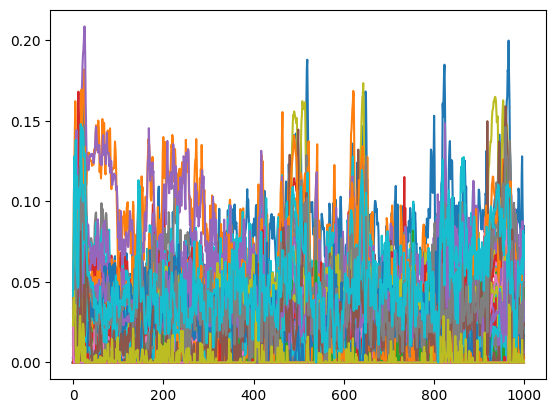

In [ ]:
out = data_rec_dic["output_rec"]
hid = data_rec_dic["hidden_rec"]

pos_rec = data_rec_dic["pos_rec"]

Wi = ag.model.W_sens_hidden.detach().cpu().numpy()
Wo = ag.model.W_hidden_out.detach().cpu().numpy()
Wh = ag.model.W_hidden.detach().cpu().numpy()

lim1=0
lim2=1000

plt.plot(np.transpose(hid[:,lim1:lim2]))

<Figure size 700x560 with 0 Axes>

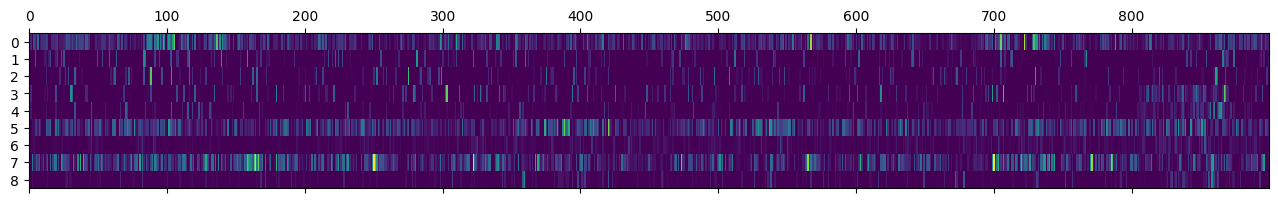

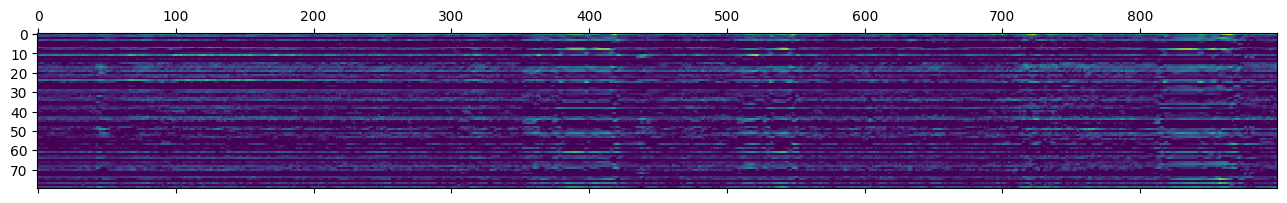

In [ ]:
fig = plt.figure(figsize=(5, 4), dpi=140)
font = {'family' : 'sans-serif',
        'weight' : 'light',
        'size'   : 10}
matplotlib.rc('font', **font)

lim1=100
lim2=1000

plt.matshow(out[:,lim1:lim2], aspect = 'auto')

plt.matshow(hid[:,lim1:lim2], aspect = 'auto')

In [ ]:
# get UMAPs

reducer = umap.UMAP(
    #n_neighbors=350,
    n_neighbors=550,
    min_dist=0.7,
    n_components=2,
)

lim_1 = 0
lim_2 = 1000

#X = np.transpose(out[:,0:500])
Xh = np.transpose(hid[:,lim_1:lim_2])
Xo = np.transpose(out[:,lim_1:lim_2])

umap_emb_hid  = reducer.fit_transform(Xh)
umap_emb_out  = reducer.fit_transform(Xo)

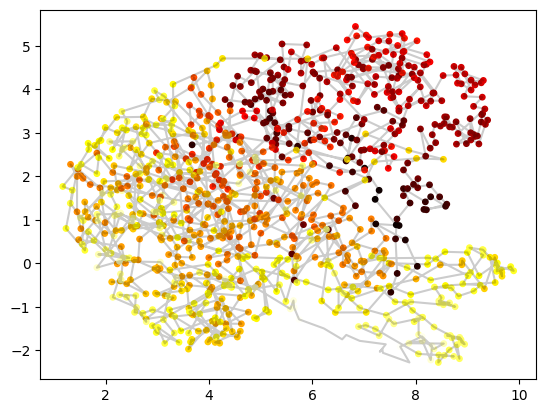

In [ ]:
ind=0
color = pos_rec[ind,:]

color = (color - np.min(color)) / (np.max(color) - np.min(color))

plt.plot(umap_emb_hid[:,0],umap_emb_hid[:,1],'k',alpha=0.2)

plt.scatter(umap_emb_hid[:,0], umap_emb_hid[:,1], s=15,marker='o',
           c= color, cmap='hot')

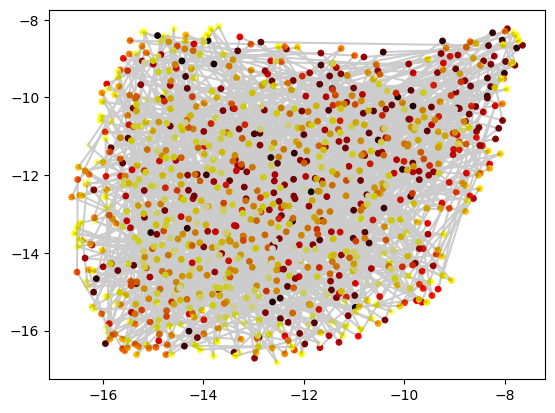

In [ ]:
ind=0
color = pos_rec[ind,:]

color = (color - np.min(color)) / (np.max(color) - np.min(color))

plt.plot(umap_emb_out[:,0],umap_emb_out[:,1],'k',alpha=0.2)

plt.scatter(umap_emb_out[:,0], umap_emb_out[:,1], s=15,marker='o',
           c= color, cmap='hot')


In [ ]:
# PCA of neural activity

pca = PCA(n_components=80)
projected_A = pca.fit_transform(Xh)  # Transpose to get time points as samples (1000x3)
projected_A = projected_A.T

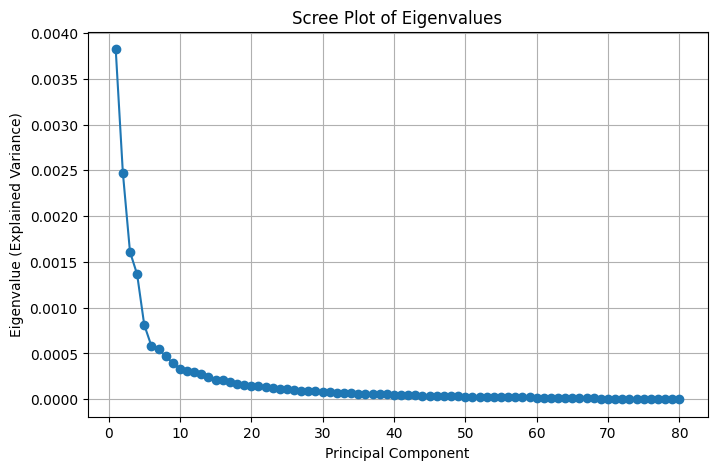

In [ ]:
# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Plot eigenvalues (scree plot)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Explained Variance)")
plt.title("Scree Plot of Eigenvalues")
plt.grid(True)
plt.show()

In [ ]:
fig = plt.figure(figsize=(5, 4), dpi=140)
font = {'family' : 'sans-serif',
        'weight' : 'light',
        'size'   : 10}
matplotlib.rc('font', **font)

lim1=100
lim2=600

plt.matshow(projected_A.T[0:8,lim1:lim2], aspect = 'auto')

ZeroDivisionError: division by zero

<Figure size 700x560 with 0 Axes>

Text(0.5, 0.92, 'Neural Trajectory in PCA Space')

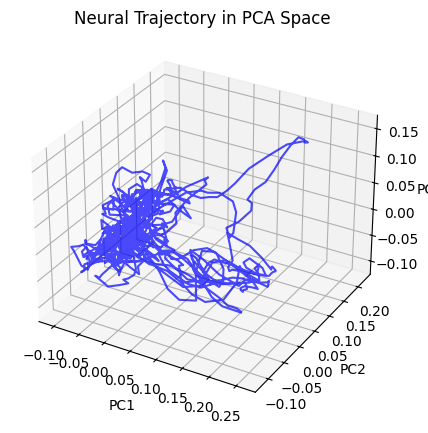

In [ ]:
projected_A = projected_A.T
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot(projected_A[:, 0], projected_A[:, 1], projected_A[:, 2], color='b', alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Neural Trajectory in PCA Space")

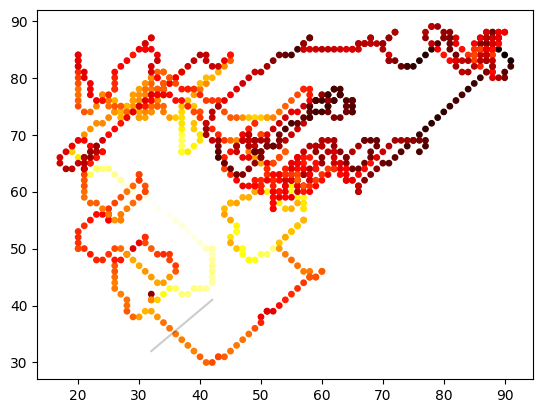

In [ ]:
ind=0
#color = hid[ind,:]

color = projected_A[:,ind]

color = (color - np.min(color)) / (np.max(color) - np.min(color))

plt.plot(pos_rec[:,0],pos_rec[:,1],'k',alpha=0.2)

plt.scatter(pos_rec[0,:], pos_rec[1,:], s=15,marker='o',
           c= color, cmap='hot')

In [ ]:
eigvals = np.linalg.eigvals(Wh)

# Magnitudes (for stability analysis)
eig_mags = np.abs(eigvals)

# Print summary
print("Eigenvalues of W_hidden:", eigvals)
print("Max eigenvalue magnitude:", np.max(eig_mags))
print("Min eigenvalue magnitude:", np.min(eig_mags))

Eigenvalues of W_hidden: [-1.4480381e+00+0.5146776j  -1.4480381e+00-0.5146776j
  1.4022017e+00+0.17902043j  1.4022017e+00-0.17902043j
  8.2369882e-01+1.1357211j   8.2369882e-01-1.1357211j
  2.1110611e-02+1.3914757j   2.1110611e-02-1.3914757j
  9.9771994e-01+0.8528816j   9.9771994e-01-0.8528816j
  1.2341692e+00+0.38356522j  1.2341692e+00-0.38356522j
 -1.1006531e+00+0.j         -6.5398425e-01+1.1134082j
 -6.5398425e-01-1.1134082j  -1.0013230e+00+0.7978969j
 -1.0013230e+00-0.7978969j   4.2615184e-01+1.1765704j
  4.2615184e-01-1.1765704j   5.8465701e-01+1.0288714j
  5.8465701e-01-1.0288714j  -2.5876999e-01+1.2274466j
 -2.5876999e-01-1.2274466j   1.0335287e+00+0.418507j
  1.0335287e+00-0.418507j    9.3733346e-01+0.6139021j
  9.3733346e-01-0.6139021j  -3.5226768e-01+1.1147454j
 -3.5226768e-01-1.1147454j  -1.0140171e+00+0.43619403j
 -1.0140171e+00-0.43619403j -6.6567905e-02+1.1260934j
 -6.6567905e-02-1.1260934j  -9.4165838e-01+0.j
 -7.8087515e-01+0.7066771j  -7.8087515e-01-0.7066771j
  2.0693

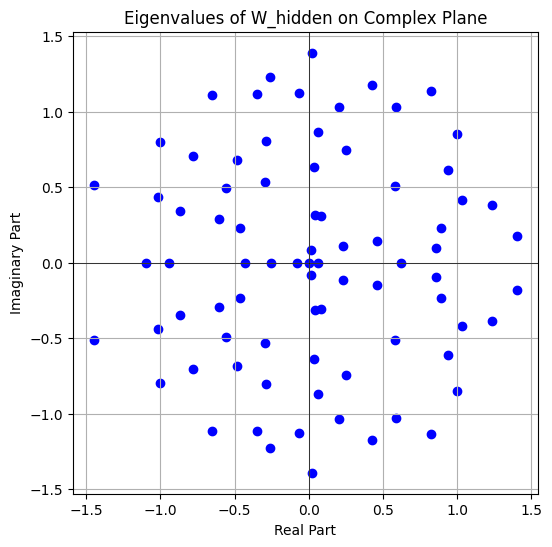

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(eigvals.real, eigvals.imag, color='blue')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Eigenvalues of W_hidden on Complex Plane')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.grid(True)
plt.show()

In [ ]:
## main training loop

generations=100000000
start_gen = 8511

version_name = "16p9_att_leakNew_fullRNN"

#pool_folder_name = "C:\\Users\\ravbar\\Desktop\\ALP_python\\pool_folder_12\\"
#pool_folder_name = "C:\\Users\\primoz\\Desktop\\USB\\python_code\\ALP\\pool_folder_12\\"
pool_folder_name = "C:\\Users\\primo\\Desktop\\USB\\ALP_python\\pool_att_16p9_leakNew_fullRNN\\"
#pool_folder_name = "C:\\Users\\ravbar\\Desktop\\ALP_python\\pool_att_16p8_leakNew_fullRNN\\"

save_records = False

eliticism = 99 # pool operations
mut_rate = 0.1
max_mut_rate = 0.1
mut_rate_of_rate = 50
mut_amp = 0.1

mut_rate_mask = 0.001
max_mut_rate_mask = 0.001
mut_rate_of_rate_mask = 1
mut_amp_mask = 1

population_episode_size = 3
min_pool_size = 250
max_pool_size = 500

max_fitness_prev = 0
sum_fitness_prev = 0

evol =  Evolution()

#solution=construct_init_solution(zero_init=False)
#solution=construct_init_solution(init_type="mixed")
solution=construct_init_solution(init_type="zeros")

fitness_vect=np.zeros((1,population_episode_size))+0.01
fitness_vect[fitness_vect<0.01]=0.01

list_elim_hidden = []
list_elim_hidden_out = []

mut_rate_vec = np.zeros((1,population_episode_size))+0.3

prev_max_fit =0

for g in range(start_gen,generations):

    popul= evol.select_popul_from_pool_1(population_episode_size,pool_folder_name)
    sol = popul[0,:]
    fitness_vect = evol.fitness_func(sol, popul)
    fitness_vect[fitness_vect<0.01]=0.01

    if np.min(fitness_vect) != 0:
        mut_rate_vec = mut_rate_of_rate/fitness_vect
        mut_rate_vec[mut_rate_vec>max_mut_rate]=max_mut_rate
    else:
        mut_rate_vec = np.zeros((1,population_episode_size))+max_mut_rate

    if np.min(fitness_vect) != 0:
        mut_rate_vec_mask = mut_rate_of_rate_mask/fitness_vect
        mut_rate_vec_mask[mut_rate_vec_mask>max_mut_rate_mask]=max_mut_rate_mask
    else:
        mut_rate_vec_mask = np.zeros((1,population_episode_size))+max_mut_rate_mask

    #popul=select_popul_from_pool_1(population_episode_size,pool_folder_name)

    for s in range(0,np.shape(popul)[0]):
        sol = popul[s,:]
        mut_rate = mut_rate_vec[0,s]
        mut_rate_mask = mut_rate_vec_mask[0,s]

        sol_next = evol.mutate(sol,mut_rate,mut_amp,mut_type="add_rand_val")
        sol_next = evol.mutate(sol_next,mut_rate_mask,mut_amp_mask,mut_type="mask")

        #####sol_next[-10:] =  np.ones((10))

        popul[s,:]=sol_next

    evol.remove_oldest_indiv(pool_folder_name, min_pool_size)
    evol.add_to_pool_1 (popul,fitness_vect,pool_folder_name, max_pool_size,gen_ind=g)

    max_fitness = np.max(fitness_vect)
    sum_fitness = np.sum(fitness_vect)

    #if g % 10 == 0:
     #   gen_rec[int(g/10),:] = popul[np.argmax(fitness_vect),:]
     #   fitness_rec[int(g/10),0] = fitness_vect[0,np.argmax(fitness_vect)]



    if save_records == True:

        if max_fitness>max_fitness_prev:

            best_solution=sol_next
            best_solution_spr = scipy.sparse.csr_matrix(best_solution)
            sol_name = 'solution_' + str(int(max_fitness)) + version_name
            with open(sol_name, "wb") as f:
                pickle.dump(best_solution_spr, f)
            popul_spr = scipy.sparse.csr_matrix(popul)
            pop_name = 'popul_' + str(int(max_fitness)) + version_name
            with open(pop_name, "wb") as f:
                pickle.dump(popul_spr, f)

            max_fitness_prev = max_fitness

        if sum_fitness>sum_fitness_prev:

            best_solution=sol_next
            best_solution_spr = scipy.sparse.csr_matrix(best_solution)
            sol_name = 'solution_' + str(int(max_fitness)) + '__sum_' +str(int(sum_fitness)) + version_name
            with open(sol_name, "wb") as f:
                pickle.dump(best_solution_spr, f)
            popul_spr = scipy.sparse.csr_matrix(popul)
            pop_name = 'popul_' + str(int(max_fitness)) + '__sum_' + str(int(sum_fitness)) + version_name
            with open(pop_name, "wb") as f:
                pickle.dump(popul_spr, f)

            sum_fitness_prev = sum_fitness

    solution = sol_next

    if  prev_max_fit <  max_fitness:

        print(f'{g}__fitness__{np.round(fitness_vect)} __ {np.round(np.sum(fitness_vect))} _mr {mut_rate} _mrm= {mut_rate_mask}')
        print("popul_neur__",np.count_nonzero(popul))

        prev_max_fit =  max_fitness